# Feb. 16th 2026 - Revisted for Enhanced Model

In [1]:
import pandas as pd
import numpy as np
import ast
from scipy import stats
from itertools import chain
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.preprocessing import MultiLabelBinarizer
import scipy.sparse as sp
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import ElasticNet
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

## Getting the Data Ready

In [2]:
#raw_interactions = pd.read_csv("RAW_interactions.csv")
raw_recipes = pd.read_csv("RAW_recipes.csv")

In [3]:
len(raw_recipes)

83782

In [4]:
raw_recipes.columns

Index(['Unnamed: 0', 'name', 'id', 'minutes', 'contributor_id', 'submitted',
       'tags', 'nutrition', 'n_steps', 'steps', 'description', 'ingredients',
       'n_ingredients'],
      dtype='str')

In [5]:
#RR = pd.merge(raw_recipes, raw_interactions, left_on = 'id', right_on = 'recipe_id', how = 'left')

In [6]:
#RR['rating'] = RR['rating'].replace(0, np.nan)

In [7]:
#average_ratings = RR.groupby('name')['rating'].mean()

In [8]:
#recipes = raw_recipes.merge(average_ratings.rename('average_rating'), on='name', how='left')

In [9]:
recipes = raw_recipes

In [10]:
recipes

,Unnamed: 0,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,111,1 brownies in the world best ever,333281,40,985201,2008-10-27,"['60-minutes-or-less', 'time-to-make', 'course...","[138.4, 10.0, 50.0, 3.0, 3.0, 19.0, 6.0]",10,['heat the oven to 350f and arrange the rack i...,"these are the most; chocolatey, moist, rich, d...","['bittersweet chocolate', 'unsalted butter', '...",9
1,115,1 in canada chocolate chip cookies,453467,45,1848091,2011-04-11,"['60-minutes-or-less', 'time-to-make', 'cuisin...","[595.1, 46.0, 211.0, 22.0, 13.0, 51.0, 26.0]",12,"['pre-heat oven the 350 degrees f', 'in a mixi...",this is the recipe that we use at my school ca...,"['white sugar', 'brown sugar', 'salt', 'margar...",11
2,118,412 broccoli casserole,306168,40,50969,2008-05-30,"['60-minutes-or-less', 'time-to-make', 'course...","[194.8, 20.0, 6.0, 32.0, 22.0, 36.0, 3.0]",6,"['preheat oven to 350 degrees', 'spray a 2 qua...",since there are already 411 recipes for brocco...,"['frozen broccoli cuts', 'cream of chicken sou...",9
3,119,millionaire pound cake,286009,120,461724,2008-02-12,"['time-to-make', 'course', 'cuisine', 'prepara...","[878.3, 63.0, 326.0, 13.0, 20.0, 123.0, 39.0]",7,"['freheat the oven to 300 degrees', 'grease a ...",why a millionaire pound cake? because it's su...,"['butter', 'sugar', 'eggs', 'all-purpose flour...",7
4,125,2000 meatloaf,475785,90,2202916,2012-03-06,"['time-to-make', 'course', 'main-ingredient', ...","[267.0, 30.0, 12.0, 12.0, 29.0, 48.0, 2.0]",17,"['pan fry bacon , and set aside on a paper tow...","ready, set, cook! special edition contest entr...","['meatloaf mixture', 'unsmoked bacon', 'goat c...",13
...,...,...,...,...,...,...,...,...,...,...,...,...,...
83777,231632,zydeco soup,486161,60,227978,2012-08-29,"['ham', '60-minutes-or-less', 'time-to-make', ...","[415.2, 26.0, 34.0, 26.0, 44.0, 21.0, 15.0]",7,"['heat oil in a 4-quart dutch oven', 'add cele...",this is a delicious soup that i originally fou...,"['celery', 'onion', 'green sweet pepper', 'gar...",22
83778,231633,zydeco spice mix,493372,5,1500678,2013-01-09,"['15-minutes-or-less', 'time-to-make', 'course...","[14.8, 0.0, 2.0, 58.0, 1.0, 0.0, 1.0]",1,['mix all ingredients together thoroughly'],this spice mix will make your taste buds dance!,"['paprika', 'salt', 'garlic powder', 'onion po...",13
83779,231634,zydeco ya ya deviled eggs,308080,40,37779,2008-06-07,"['60-minutes-or-less', 'time-to-make', 'course...","[59.2, 6.0, 2.0, 3.0, 6.0, 5.0, 0.0]",7,"['in a bowl , combine the mashed yolks and may...","deviled eggs, cajun-style","['hard-cooked eggs', 'mayonnaise', 'dijon must...",8
83780,231635,cookies by design cookies on a stick,298512,29,506822,2008-04-15,"['30-minutes-or-less', 'time-to-make', 'course...","[188.0, 11.0, 57.0, 11.0, 7.0, 21.0, 9.0]",9,['place melted butter in a large mixing bowl a...,"i've heard of the 'cookies by design' company,...","['butter', 'eagle brand condensed milk', 'ligh...",10


In [11]:
recipes['ingredients'] = recipes['ingredients'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

In [12]:
recipes['tags'] = recipes['tags'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

In [13]:
mask_all_blank = recipes["tags"].apply(
    lambda x: isinstance(x, list) and len(x) > 0 and all(
        isinstance(t, str) and t.strip() == "" for t in x
    )
)

recipes.loc[mask_all_blank, "tags"]

473      []
550      []
601      []
1941     []
2853     []
         ..
79623    []
80780    []
81658    []
82435    []
83543    []
Name: tags, Length: 101, dtype: object

## Missingness Analysis on 'tags' column

In [14]:
def is_tags_missing(x):
    if not isinstance(x, list):
        return True
    meaningful = [t for t in x if isinstance(t, str) and t.strip()]
    return len(meaningful) == 0

tags_missing = recipes['tags'].apply(is_tags_missing)

n_missing = tags_missing.sum()
n_total = len(recipes)
print(f"Total recipes: {n_total:,}")
print(f"Missing tags:  {n_missing:,} ({n_missing / n_total * 100:.2f}%)")
print(f"Has tags:      {n_total - n_missing:,} ({(n_total - n_missing) / n_total * 100:.2f}%)")

Total recipes: 83,782
Missing tags:  101 (0.12%)
Has tags:      83,681 (99.88%)


In [15]:
has_tags = recipes[~tags_missing]
no_tags = recipes[tags_missing]

if n_missing == 0:
    print("No missing tags found — nothing to compare.")
else:
    compare_cols = ['minutes', 'n_steps', 'n_ingredients']
    comparison = pd.DataFrame({
        'has_tags_mean': has_tags[compare_cols].mean(),
        'no_tags_mean': no_tags[compare_cols].mean(),
        'has_tags_median': has_tags[compare_cols].median(),
        'no_tags_median': no_tags[compare_cols].median(),
        'has_tags_std': has_tags[compare_cols].std(),
        'no_tags_std': no_tags[compare_cols].std(),
    })
    comparison

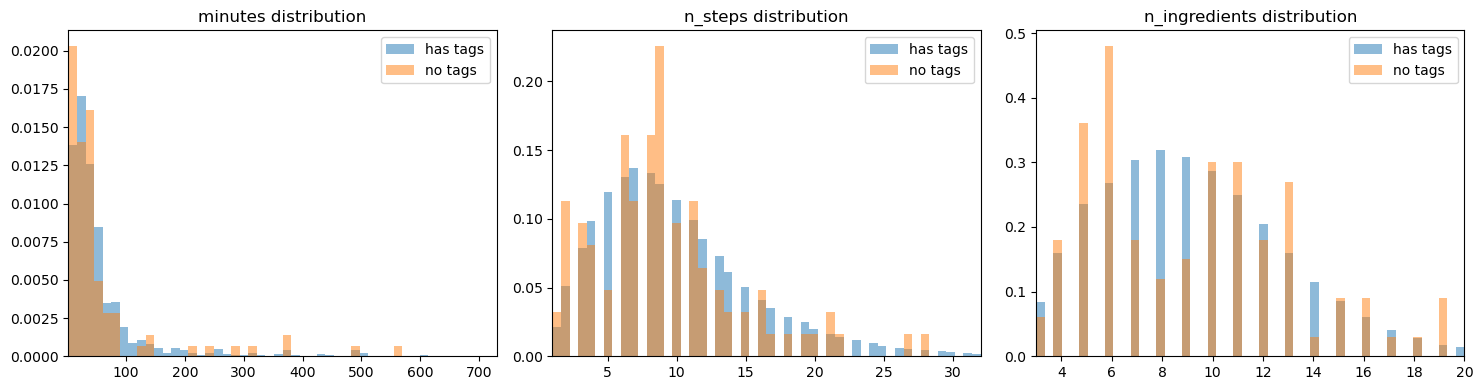

In [16]:
if n_missing > 0:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for ax, col in zip(axes, compare_cols):
        combined = pd.concat([has_tags[col], no_tags[col]]).dropna()
        lo, hi = combined.quantile(0.01), combined.quantile(0.99)
        bins = np.linspace(lo, hi, 51)

        ax.hist(has_tags[col], bins=bins, alpha=0.5, label='has tags', density=True)
        ax.hist(no_tags[col], bins=bins, alpha=0.5, label='no tags', density=True)
        ax.set_title(f'{col} distribution')
        ax.set_xlim(lo, hi)
        ax.legend()

    plt.tight_layout()
    plt.show()

In [17]:
if n_missing > 0:
    from scipy.stats import mannwhitneyu

    print("Mann-Whitney U tests (has tags vs no tags):\n")
    for col in compare_cols:
        stat, p = mannwhitneyu(
            has_tags[col].dropna(), no_tags[col].dropna(), alternative='two-sided'
        )
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."
        print(f"  {col:20s}  U = {stat:>12,.0f}   p = {p:.4e}  {sig}")

Mann-Whitney U tests (has tags vs no tags):

  minutes               U =    4,543,160   p = 1.9103e-01  n.s.
  n_steps               U =    4,535,771   p = 2.0122e-01  n.s.
  n_ingredients         U =    4,229,591   p = 9.8781e-01  n.s.


/var/folders/94/btrbc35j36x_13n43_9kv69w0000gn/T/ipykernel_3324/2245320136.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


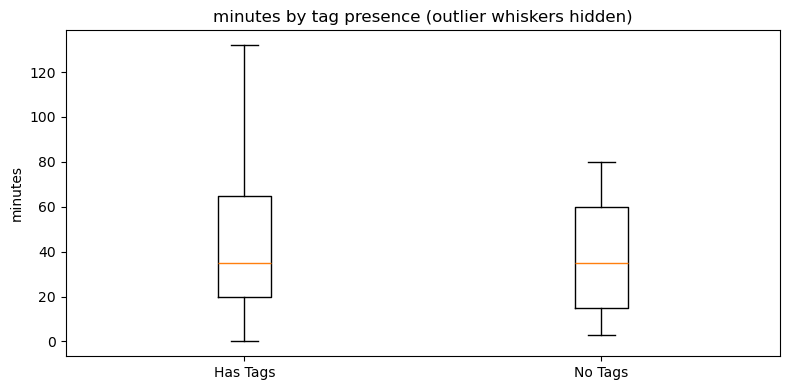

In [18]:
if n_missing > 0:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.boxplot(
        [has_tags['minutes'].dropna(), no_tags['minutes'].dropna()],
        labels=['Has Tags', 'No Tags'],
        showfliers=False
    )
    ax.set_ylabel('minutes')
    ax.set_title('minutes by tag presence (outlier whiskers hidden)')
    plt.tight_layout()
    plt.show()

In [19]:
recipes = recipes[recipes["ingredients"].str.len() > 0].copy()

## Outliers

In [20]:
Q1 = recipes['minutes'].quantile(0.25)
Q3 = recipes['minutes'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
iqr_outliers = recipes[(recipes['minutes'] < lower_bound) | 
                           (recipes['minutes'] > upper_bound)]
print(f"\nOutliers using IQR method: {len(iqr_outliers)}")
print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")
print(iqr_outliers.head())


Outliers using IQR method: 7991
Lower bound: -47.5, Upper bound: 132.5
    Unnamed: 0                                name      id  minutes  \
6          132         50 chili   for the crockpot  501028      345   
11         139  rter med flsk   pea soup with pork  333797      195   
12         140    rtsoppa  swedish yellow pea soup  428056      150   
34         257        posh   pork roast   crockpot  451515      315   
39         266               russian  dressing  ww  276567      135   

    contributor_id   submitted  \
6          2628680  2013-05-28   
11           64642  2008-10-29   
12          618715  2010-06-01   
34           50969  2011-03-24   
39          305531  2008-01-05   

                                                 tags  \
6   [course, main-ingredient, cuisine, preparation...   
11  [time-to-make, course, main-ingredient, cuisin...   
12  [time-to-make, course, main-ingredient, cuisin...   
34  [course, main-ingredient, cuisine, preparation...   
39  [time-t

In [21]:
median = recipes['minutes'].median()
mad = stats.median_abs_deviation(recipes['minutes'])
modified_z_scores = 0.6745 * (recipes['minutes'] - median) / mad
recipes['modified_z_scores'] = modified_z_scores
mod_z_outliers = recipes[abs(modified_z_scores) > 3.5]
print(f"\nOutliers using Modified Z-score method: {len(mod_z_outliers)}")
print(mod_z_outliers.head())


Outliers using Modified Z-score method: 7496
    Unnamed: 0                                name      id  minutes  \
6          132         50 chili   for the crockpot  501028      345   
11         139  rter med flsk   pea soup with pork  333797      195   
12         140    rtsoppa  swedish yellow pea soup  428056      150   
34         257        posh   pork roast   crockpot  451515      315   
46         289                    the  carrot cake  325714     1500   

    contributor_id   submitted  \
6          2628680  2013-05-28   
11           64642  2008-10-29   
12          618715  2010-06-01   
34           50969  2011-03-24   
46          817632  2008-09-19   

                                                 tags  \
6   [course, main-ingredient, cuisine, preparation...   
11  [time-to-make, course, main-ingredient, cuisin...   
12  [time-to-make, course, main-ingredient, cuisin...   
34  [course, main-ingredient, cuisine, preparation...   
46  [time-to-make, course, preparatio

In [22]:
len(mod_z_outliers)

7496

In [23]:
recipes_clean = recipes[abs(recipes['modified_z_scores']) <= 3.5].copy()
print(f"Original dataset size: {len(recipes)}")
print(f"Clean dataset size: {len(recipes_clean)}")
print(f"Removed {len(recipes) - len(recipes_clean)} outliers")

Original dataset size: 83782
Clean dataset size: 76286
Removed 7496 outliers


In [24]:
recipes_clean = recipes_clean[['ingredients', 'tags', 'minutes']]

In [25]:
recipes_clean

,ingredients,tags,minutes
0,"[bittersweet chocolate, unsalted butter, eggs,...","[60-minutes-or-less, time-to-make, course, mai...",40
1,"[white sugar, brown sugar, salt, margarine, eg...","[60-minutes-or-less, time-to-make, cuisine, pr...",45
2,"[frozen broccoli cuts, cream of chicken soup, ...","[60-minutes-or-less, time-to-make, course, mai...",40
3,"[butter, sugar, eggs, all-purpose flour, whole...","[time-to-make, course, cuisine, preparation, o...",120
4,"[meatloaf mixture, unsmoked bacon, goat cheese...","[time-to-make, course, main-ingredient, prepar...",90
...,...,...,...
83777,"[celery, onion, green sweet pepper, garlic clo...","[ham, 60-minutes-or-less, time-to-make, course...",60
83778,"[paprika, salt, garlic powder, onion powder, d...","[15-minutes-or-less, time-to-make, course, pre...",5
83779,"[hard-cooked eggs, mayonnaise, dijon mustard, ...","[60-minutes-or-less, time-to-make, course, mai...",40
83780,"[butter, eagle brand condensed milk, light bro...","[30-minutes-or-less, time-to-make, course, pre...",29


In [26]:
recipes_clean = recipes_clean[~recipes_clean["tags"].apply(is_tags_missing)].copy()
recipes_clean

,ingredients,tags,minutes
0,"[bittersweet chocolate, unsalted butter, eggs,...","[60-minutes-or-less, time-to-make, course, mai...",40
1,"[white sugar, brown sugar, salt, margarine, eg...","[60-minutes-or-less, time-to-make, cuisine, pr...",45
2,"[frozen broccoli cuts, cream of chicken soup, ...","[60-minutes-or-less, time-to-make, course, mai...",40
3,"[butter, sugar, eggs, all-purpose flour, whole...","[time-to-make, course, cuisine, preparation, o...",120
4,"[meatloaf mixture, unsmoked bacon, goat cheese...","[time-to-make, course, main-ingredient, prepar...",90
...,...,...,...
83777,"[celery, onion, green sweet pepper, garlic clo...","[ham, 60-minutes-or-less, time-to-make, course...",60
83778,"[paprika, salt, garlic powder, onion powder, d...","[15-minutes-or-less, time-to-make, course, pre...",5
83779,"[hard-cooked eggs, mayonnaise, dijon mustard, ...","[60-minutes-or-less, time-to-make, course, mai...",40
83780,"[butter, eagle brand condensed milk, light bro...","[30-minutes-or-less, time-to-make, course, pre...",29


In [27]:
tags_missing = recipes_clean['tags'].apply(is_tags_missing)

n_missing = tags_missing.sum()

print(n_missing)

0


## Model Pipeline

In [28]:
X = recipes_clean[['ingredients', 'tags']]

In [29]:
y = recipes_clean['minutes']

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X , y, test_size = 0.2, random_state = 44)

In [31]:
X_train, y_train

(                                             ingredients  \
 26318  [milk, water, butter, steel cut oats, tea bags...   
 9300        [blue cheese, butter, garlic cloves, chives]   
 71166  [reduced-sodium chicken broth, chicken broth, ...   
 18237  [butter, molasses, brown sugar, flour, ground ...   
 15864  [boneless chicken breast, alfredo sauce, farfa...   
 ...                                                  ...   
 58269  [lean ground beef, green bell pepper, green on...   
 54618  [crabmeat, celery, fresh chives, mayonnaise, e...   
 28467  [all-purpose flour, sugar, baking soda, salt, ...   
 76009  [eggplant, basil, lemon zest, extra virgin oli...   
 15300  [cooked chicken, iceberg lettuce, avocado, tom...   
 
                                                     tags  
 26318  [30-minutes-or-less, time-to-make, course, mai...  
 9300   [15-minutes-or-less, time-to-make, course, pre...  
 71166  [30-minutes-or-less, time-to-make, course, mai...  
 18237  [time-to-make, cou

In [32]:
mlb_ingredients = MultiLabelBinarizer(sparse_output=True)
train_ingredients = mlb_ingredients.fit_transform(X_train['ingredients'])

In [33]:
mlb_tags = MultiLabelBinarizer(sparse_output=True)
train_tags = mlb_tags.fit_transform(X_train['tags'])

In [34]:
test_ingredients = mlb_ingredients.transform(X_test['ingredients'])

/Users/jhkim/miniforge3/envs/RR_enhanced/lib/python3.14/site-packages/sklearn/preprocessing/_label.py:1007: UserWarning: unknown class(es) ['6-inch corn tortillas', '8-inch graham cracker crust', '9" pastry pie shells', '9-grain bread', '97% lean ground beef', '98% fat free condensed cream of celery soup', '98% fat-free honey ham', 'absolut kurant vodka', 'after dinner mints', 'aji panca chilies', 'ajinomoto', 'alligator meat', 'alligator tail steaks', 'almond granola', 'almond halve', 'almond halves', 'alouette spinach artichoke spreadable cheese', 'amaranth grain', 'anchovy packed in oil', 'animal crackers', 'apple liqueur', 'apricot conserve', 'apricot liqueur', 'apricot-pineapple preserves', 'artichoke pesto', 'artichoke quarters in water', 'artificial vanilla flavoring', 'asiago caesar salad dressing', 'astragalus root', 'atkins baking mix', 'baby octopus', 'bacardi peach red rum', 'balsamic syrup', 'banana flower', 'barbecued beef', 'bay bugs', 'bean with bacon soup', 'beans in c

In [35]:
test_tags = mlb_tags.transform(X_test['tags'])

/Users/jhkim/miniforge3/envs/RR_enhanced/lib/python3.14/site-packages/sklearn/preprocessing/_label.py:1007: UserWarning: unknown class(es) ['beef-kidney', 'heirloom-historical-recipes', 'irish-st-patricks-day'] will be ignored
  warnings.warn(


In [36]:
train_stack = sp.hstack([train_ingredients, train_tags], format='csr')

In [37]:
test_stack = sp.hstack([test_ingredients, test_tags], format='csr')

In [38]:
train_stack

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 1552718 stored elements and shape (60957, 10627)>

In [39]:
y_train

26318    25
9300     15
71166    20
18237    75
15864    25
         ..
58269    50
54618    40
28467    50
76009    65
15300    15
Name: minutes, Length: 60957, dtype: int64

Lot of unknown classes. Common for high-cardinality sparse features. Baseline model for quick sanity and reference point. Making sure to: validate preprocessing pipeline, set a performance floor. 

## Baseline Model - Dummy Regressor

In [40]:
dummy_regr = DummyRegressor(strategy='mean')
dummy_regr.fit(train_stack, y_train)

,"strategy strategy: {""mean"", ""median"", ""quantile"", ""constant""}, default=""mean""Strategy to use to generate predictions.* ""mean"": always predicts the mean of the training set* ""median"": always predicts the median of the training set* ""quantile"": always predicts a specified quantile of the training set, provided with the quantile parameter.* ""constant"": always predicts a constant value that is provided by the user.",'mean'
,"constant constant: int or float or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
,"quantile quantile: float in [0.0, 1.0], default=NoneThe quantile to predict using the ""quantile"" strategy. A quantile of0.5 corresponds to the median, while 0.0 to the minimum and 1.0 to themaximum.",None


In [41]:
dummy_pred = dummy_regr.predict(test_stack)
#R^2
dummy_regr.score(test_stack, y_test)

-4.012351500404243e-05

In [42]:
#MAE
mean_absolute_error( y_test, dummy_pred)

21.485450838651076

In [43]:
#RMSE
root_mean_squared_error(y_test, dummy_pred)

27.456999257219078

## Baseline Model - ElasticNet

In [44]:
regr = ElasticNet(random_state = 68)
regr.fit(train_stack, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",1.0
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",68
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [45]:
pred = regr.predict(test_stack)
regr.score(test_stack, y_test)

0.44163436777000453

In [46]:
mean_absolute_error(y_test, pred)

15.554803142282045

In [47]:
root_mean_squared_error(y_test, pred)

20.51652005584444

You can see that ElasticNet model does perform better meaning our prerprocessing pipeline is working and the model is learning singals. Our earlier concern about unknown classes are also proven to be not fatal. On to XGBoost

## XGBoost Model

In [48]:
xgb = XGBRegressor(
    objective = 'reg:squarederror',
    tree_method = 'hist',
    random_state = 27, 
    n_jobs = -1
)

In [49]:
param_dist = {
    'n_estimators': [300, 500, 700],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [4, 6, 8],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.01, 0.1],
    'reg_lambda': [1, 3, 10]
}

In [50]:
cv = KFold(n_splits = 5, shuffle = True, random_state = 44)

In [51]:
search = RandomizedSearchCV(
    estimator = xgb,
    param_distributions = param_dist,
    n_iter = 25,
    scoring = 'neg_root_mean_squared_error',
    cv = cv,
    random_state = 44,
    verbose = 2,
    n_jobs = -1,
    refit = True
)

In [52]:
search.fit(train_stack, y_train)

print("Best params:", search.best_params_)
print("Best CV RMSE:", -search.best_score_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=4, min_child_weight=1, n_estimators=700, reg_alpha=0.1, reg_lambda=3, subsample=0.85; total time=   6.3s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=4, min_child_weight=1, n_estimators=700, reg_alpha=0.1, reg_lambda=3, subsample=0.85; total time=   6.6s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=4, min_child_weight=1, n_estimators=700, reg_alpha=0.1, reg_lambda=3, subsample=0.85; total time=   6.7s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=4, min_child_weight=1, n_estimators=700, reg_alpha=0.1, reg_lambda=3, subsample=0.85; total time=   6.8s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=4, min_child_weight=1, n_estimators=700, reg_alpha=0.1, reg_lambda=3, subsample=0.85; total time=   7.0s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=8, min_child_weight=3, n_estimators=300, reg_alpha=0

In [53]:
best_xgb = search.best_estimator_
xgb_pred = best_xgb.predict(test_stack)

xgb_rmse = root_mean_squared_error(y_test, xgb_pred)
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

print(f"XGB Test RMSE: {xgb_rmse:.3f}")
print(f"XGB Test MAE : {xgb_mae:.3f}")
print(f"XGB Test R^2 : {xgb_r2:.3f}")

XGB Test RMSE: 9.735
XGB Test MAE : 6.675
XGB Test R^2 : 0.874


## XGBoost Second Round Tuning

In [59]:
param_dist_2 = {
    'n_estimators': [300, 500, 700],
    'learning_rate': [0.01, 0.02, 0.03],
    'max_depth': [8, 10, 12],
    'min_child_weight': [2, 3, 4],
    'subsample': [0.6, 0.7, 0.8],
    'colsample_bytree': [0.4, 0.5, 0.6],
    'reg_alpha': [0.005, 0.01, 0.02],
    'reg_lambda': [2, 3, 5],
    'gamma': [0, 0.5, 1.0]
}

In [60]:
cv_2 = KFold(
    n_splits=5,
    shuffle=True,
    random_state=44
)

In [61]:
search_2 = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist_2,
    n_iter=25,
    scoring="neg_root_mean_squared_error",
    cv=cv_2,
    random_state=44,
    verbose=2,
    n_jobs=-1,
    refit=True
)

In [62]:
search_2.fit(train_stack, y_train)

print("Best params:", search.best_params_)
print("Best CV RMSE:", -search.best_score_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.02, max_depth=10, min_child_weight=2, n_estimators=300, reg_alpha=0.005, reg_lambda=5, subsample=0.6; total time=  23.2s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.02, max_depth=10, min_child_weight=2, n_estimators=300, reg_alpha=0.005, reg_lambda=5, subsample=0.6; total time=  23.7s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.02, max_depth=10, min_child_weight=2, n_estimators=300, reg_alpha=0.005, reg_lambda=5, subsample=0.6; total time=  24.1s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.02, max_depth=10, min_child_weight=2, n_estimators=300, reg_alpha=0.005, reg_lambda=5, subsample=0.6; total time=  24.1s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.02, max_depth=10, min_child_weight=2, n_estimators=300, reg_alpha=0.005, reg_lambda=5, subsample=0.6; total time=  24.7s
[CV] END colsample_bytree=0.4, gamma=0.5, learning_ra

In [63]:
best_xgb = search_2.best_estimator_
xgb_pred = best_xgb.predict(test_stack)

xgb_rmse = root_mean_squared_error(y_test, xgb_pred)
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

print(f"XGB Test RMSE: {xgb_rmse:.3f}")
print(f"XGB Test MAE : {xgb_mae:.3f}")
print(f"XGB Test R^2 : {xgb_r2:.3f}")

XGB Test RMSE: 9.707
XGB Test MAE : 6.633
XGB Test R^2 : 0.875


## Residual Analysis

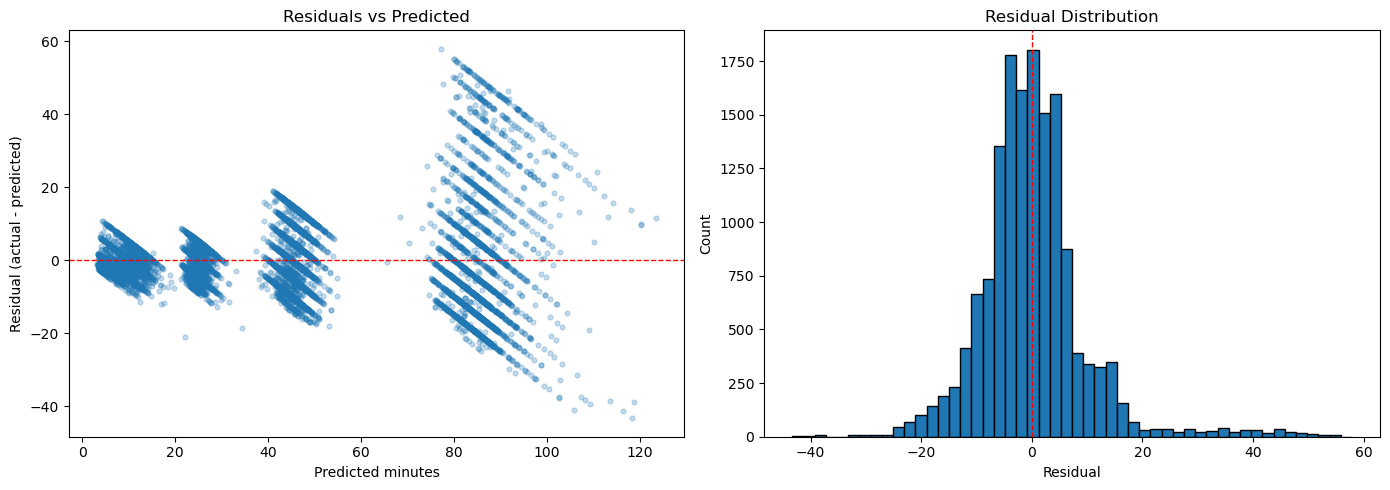

In [64]:
# Ensure same index alignment
y_test_series = pd.Series(y_test).reset_index(drop=True)
y_pred_series = pd.Series(xgb_pred).reset_index(drop=True)

residuals = y_test_series - y_pred_series

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred_series, residuals, alpha=0.25, s=12)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel("Predicted minutes")
axes[0].set_ylabel("Residual (actual - predicted)")
axes[0].set_title("Residuals vs Predicted")

# Residual distribution
axes[1].hist(residuals, bins=50, edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

## Error by Bins

In [65]:
eval_df = pd.DataFrame({
    "actual": y_test_series,
    "pred": y_pred_series
})
eval_df["abs_error"] = (eval_df["actual"] - eval_df["pred"]).abs()
eval_df["sq_error"] = (eval_df["actual"] - eval_df["pred"]) ** 2

# Adjust bins if you want finer granularity
bins = [0, 15, 30, 45, 60, 90, 120, np.inf]
labels = ["0-15", "15-30", "30-45", "45-60", "60-90", "90-120", "120+"]

eval_df["minute_bin"] = pd.cut(eval_df["actual"], bins=bins, labels=labels, right=False)

bin_summary = (
    eval_df.groupby("minute_bin", observed=False)
    .agg(
        n=("actual", "size"),
        mae=("abs_error", "mean"),
        rmse=("sq_error", lambda x: np.sqrt(np.mean(x))),
        actual_mean=("actual", "mean"),
        pred_mean=("pred", "mean")
    )
    .reset_index()
)

bin_summary

,minute_bin,n,mae,rmse,actual_mean,pred_mean
0,0-15,2431,2.589847,3.280412,7.268202,8.839620
1,15-30,3661,3.285249,3.968835,20.458891,21.531721
2,30-45,3569,6.367857,7.053707,34.557579,37.279854
3,45-60,2146,4.282425,5.465976,49.243709,45.850803
4,60-90,2433,12.396926,13.776812,68.898890,72.564240
5,90-120,663,11.932643,14.373329,97.556561,86.257339
6,120+,337,37.911074,38.973080,127.658754,89.747681


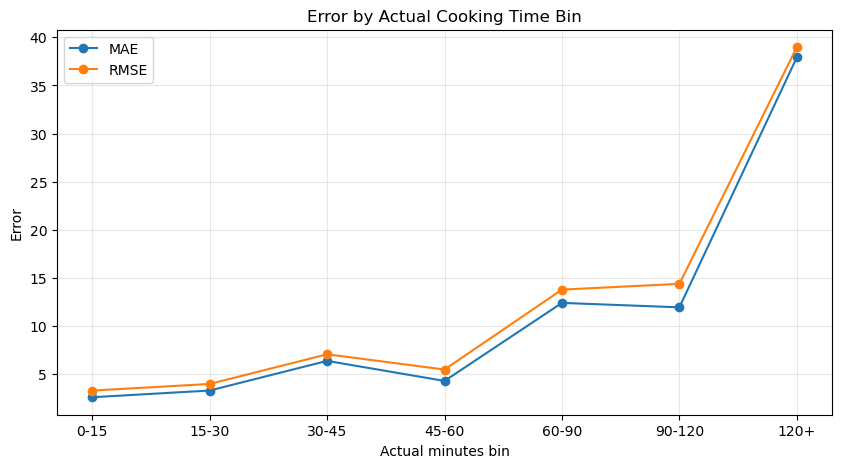

In [66]:
plt.figure(figsize=(10, 5))
plt.plot(bin_summary["minute_bin"].astype(str), bin_summary["mae"], marker="o", label="MAE")
plt.plot(bin_summary["minute_bin"].astype(str), bin_summary["rmse"], marker="o", label="RMSE")
plt.xlabel("Actual minutes bin")
plt.ylabel("Error")
plt.title("Error by Actual Cooking Time Bin")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Feature Importance

In [67]:
# Build feature names from your MLB encoders
feature_names = (
    [f"ing::{c}" for c in mlb_ingredients.classes_] +
    [f"tag::{c}" for c in mlb_tags.classes_]
)

# XGBoost native importance (gain-based)
booster = best_xgb.get_booster()
score_gain = booster.get_score(importance_type="gain")  # keys like 'f0', 'f1', ...

# Convert to readable table
rows = []
for k, v in score_gain.items():
    idx = int(k[1:])  # from "f123" -> 123
    name = feature_names[idx] if idx < len(feature_names) else k
    rows.append((name, v))

importance_gain_df = pd.DataFrame(rows, columns=["feature", "gain_importance"])
importance_gain_df = importance_gain_df.sort_values("gain_importance", ascending=False).reset_index(drop=True)

importance_gain_df.head(20)

,feature,gain_importance
0,tag::4-hours-or-less,669762.250000
1,tag::15-minutes-or-less,334950.062500
2,tag::60-minutes-or-less,145882.734375
3,tag::30-minutes-or-less,106526.617188
4,tag::for-1-or-2,22409.039062
5,tag::beverages,16120.485352
6,ing::crisp rice cereal,10481.742188
7,tag::crock-pot-slow-cooker,8408.636719
8,tag::whole-chicken,7028.567383
9,ing::rotisserie-cooked chicken,6024.626953


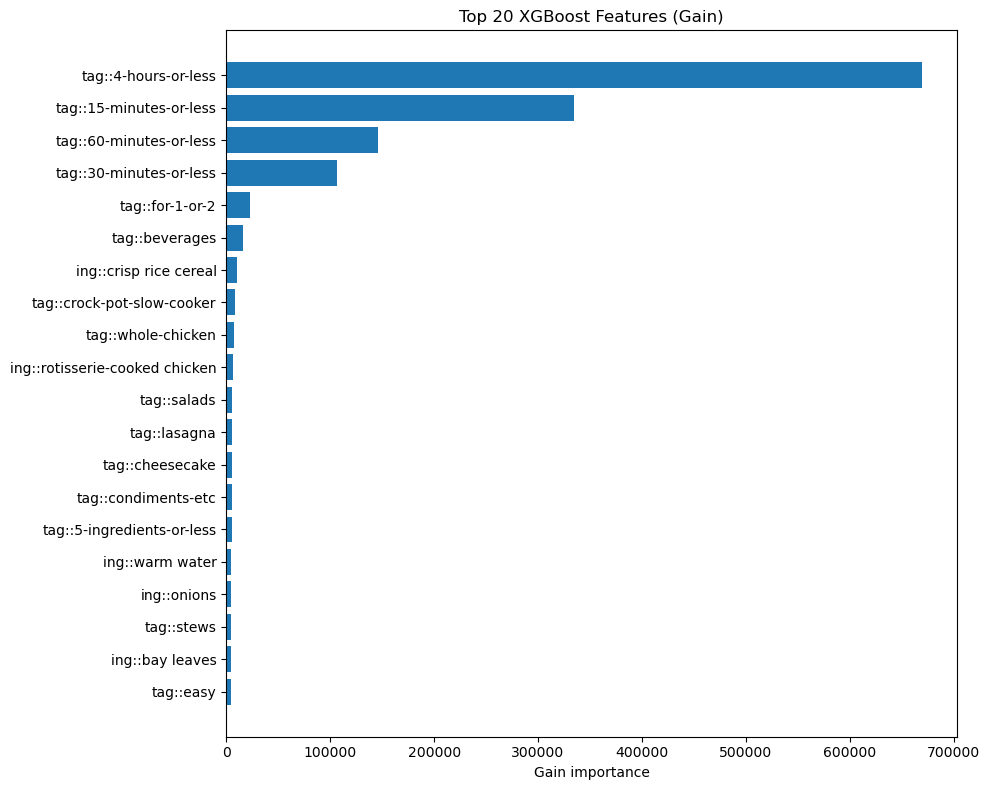

In [68]:
top_n = 20
top_gain = importance_gain_df.head(top_n).iloc[::-1]  # reverse for horizontal bar chart

plt.figure(figsize=(10, 8))
plt.barh(top_gain["feature"], top_gain["gain_importance"])
plt.xlabel("Gain importance")
plt.title(f"Top {top_n} XGBoost Features (Gain)")
plt.tight_layout()
plt.show()